# Diez reglas simples para mejores figuras (científicas en Python)

#### Basado en: Rougier, Droettboom & Bourne (2014), *PLOS Computational Biology*

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

In [1]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

#!pip install colorspacious

import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


In [2]:

# ── Semilla fija: todas las figuras son reproducibles ───────────────────
np.random.seed(42)

meses = np.arange(1, 13)
nm    = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
T_media = 22 + 1.5*np.sin(2*np.pi*(meses-4)/12) - 0.8*np.cos(4*np.pi*(meses-1)/12)
T_max   = T_media + 5 + 0.5*np.random.randn(12)
T_min   = T_media - 4 + 0.5*np.random.randn(12)
lluvia  = np.clip(
    80 + 60*np.sin(2*np.pi*(meses-4)/12)
       + 40*np.cos(4*np.pi*(meses-1)/12)
       + 10*np.random.randn(12), 20, 200)

N = 120
x_e = np.linspace(0, np.pi, N); y_e = np.linspace(0, np.pi, N)
X_e, Y_e = np.meshgrid(x_e, y_e)
U_e = np.sinh(Y_e) / np.sinh(np.pi) * np.sin(X_e)

fac = ['Ciencias','Ingeniería','Artes','Medicina','Derecho']
apr = np.array([78, 82, 71, 88, 74])
des = np.array([12, 15, 20,  8, 18])

h      = np.logspace(-4, -1, 20)
e_eu   = 0.5  * h**1
e_rk2  = 0.08 * h**2
e_rk4  = 0.003* h**4

COL_T = '#E05C2A'   # naranja: temperatura
COL_L = '#3A7DC9'   # azul: lluvia / barras

print('Datasets cargados.')

Datasets cargados.


---
# Regla 1 — Conoce tu audiencia

La audiencia determina el nivel de detalle, el tamaño de los elementos visuales y la cantidad de información. La misma figura **no** sirve igual para un artículo, una presentación y el público general.

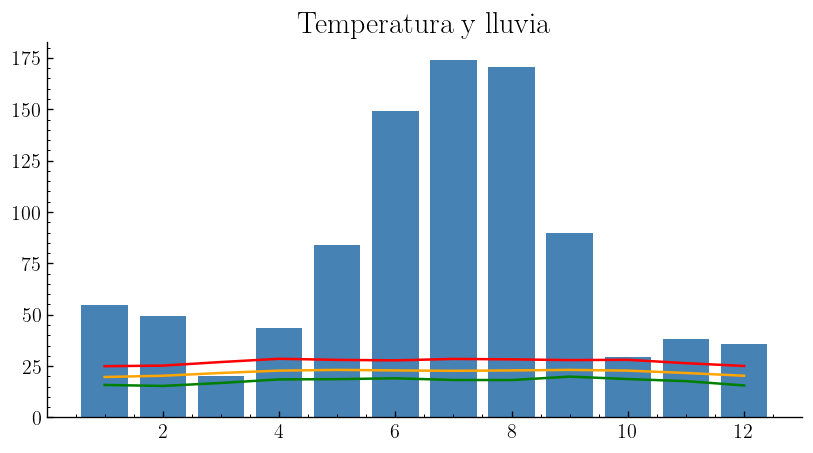

Problemas: escala incompatible, sin unidades, sin leyenda, eje x con números.


In [3]:
# ─── ANTES: sin audiencia definida ─────────────────────────────────────────
# Temperatura y lluvia en el mismo eje, sin unidades, sin leyenda
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(meses, lluvia, color='steelblue')
ax.plot(meses, T_media, color='orange')
ax.plot(meses, T_max,   color='red')
ax.plot(meses, T_min,   color='green')
ax.set_title('Temperatura y lluvia')  # título vago
# Sin xlabel, sin ylabel, sin unidades, sin nombres de meses
plt.tight_layout(); plt.show()
print('Problemas: escala incompatible, sin unidades, sin leyenda, eje x con números.')

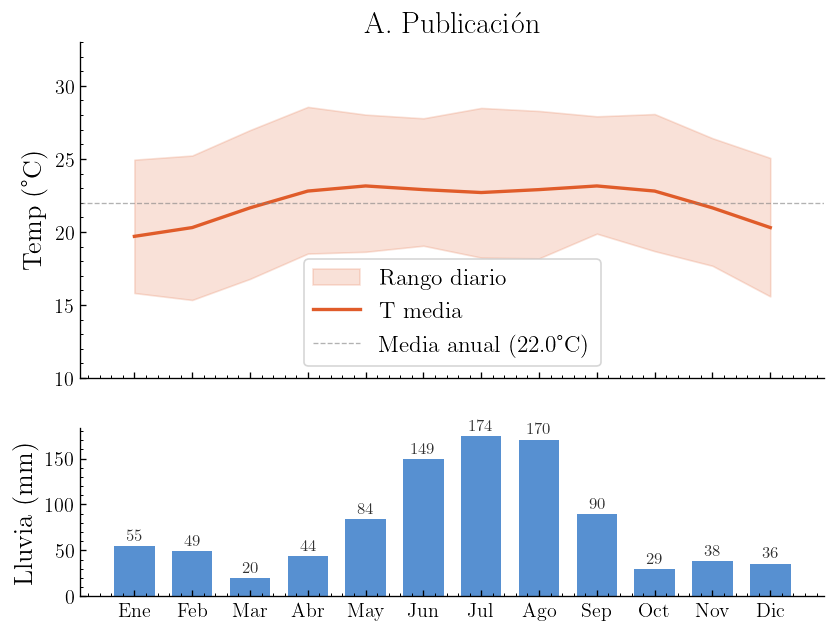

In [4]:
# A. Publicación: doble panel, valores anotados, leyenda, media de referencia
fig_A, (axA1, axA2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel Superior: Temperatura ---
axA1.fill_between(meses, T_min, T_max, alpha=0.18, color=COL_T, label='Rango diario')
axA1.plot(meses, T_media, color=COL_T, lw=2, label='T media')
axA1.axhline(T_media.mean(), color='gray', lw=0.8, ls='--', alpha=0.6, 
             label=f'Media anual ({T_media.mean():.1f}°C)')

axA1.set_ylabel('Temp (°C)')
axA1.set_ylim(10, 33)
axA1.legend( )
axA1.tick_params(labelbottom=False)
axA1.set_title('A. Publicación')

# --- Panel Inferior: Lluvia ---
axA2.bar(meses, lluvia, color=COL_L, alpha=0.85, width=0.7)
axA2.set_ylabel('Lluvia (mm)')
axA2.set_xticks(meses)
axA2.set_xticklabels(nm)
axA2.spines['top'].set_visible(False)
axA2.spines['right'].set_visible(False)
axA2.tick_params( )

# Anotación de valores sobre cada barra
for m, ll in zip(meses, lluvia):
    axA2.text(m, ll+3, f'{ll:.0f}', ha='center', va='bottom', fontsize=10, color='#333')

plt.show()

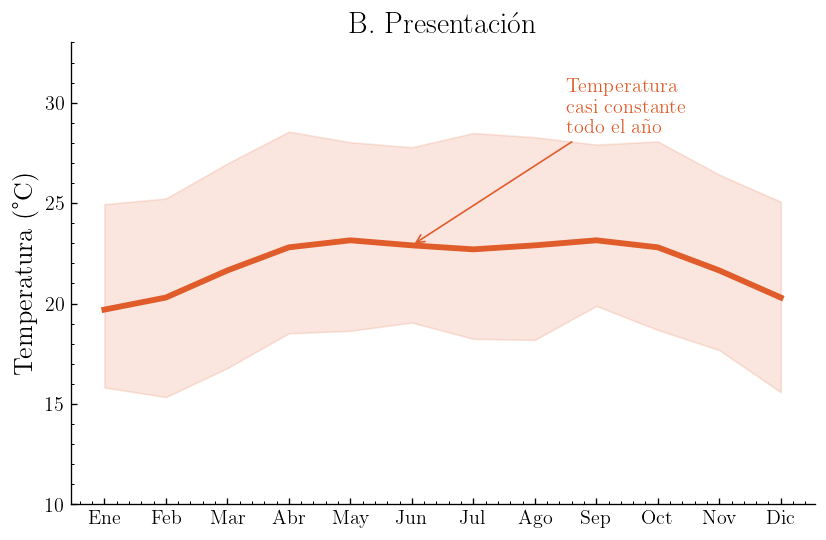

In [5]:
# B. Clase: línea gruesa, texto grande, anotación del mensaje
fig_B, axB = plt.subplots(figsize=(8, 5))

# Trazado de temperatura
axB.fill_between(meses, T_min, T_max, alpha=0.15, color=COL_T)
axB.plot(meses, T_media, color=COL_T, lw=3.5)

# Configuración de ejes y estética
axB.set_ylabel('Temperatura (°C)')
axB.set_xticks(meses)
axB.set_xticklabels(nm)

axB.set_ylim(10, 33)

# Anotación con flecha
texto = 'Temperatura\ncasi constante\ntodo el año'
axB.annotate(texto, xy=(6, T_media[5]), xytext=(8.5, 28.5), fontsize=12, 
             color=COL_T, fontweight='bold', arrowprops=dict(arrowstyle='->', color=COL_T, lw=1))

axB.set_title('B. Presentación')

plt.show()

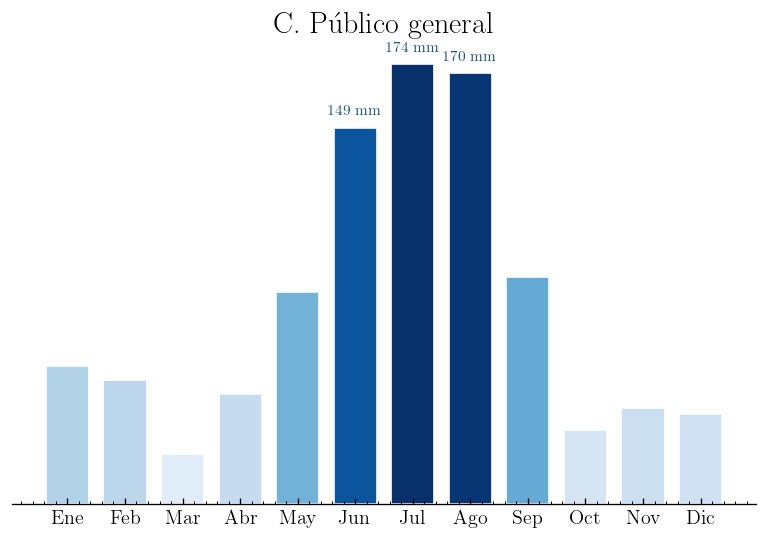

In [6]:
# C. Público general: color reemplaza el eje, solo valores llamativos
fig_C, axC = plt.subplots(figsize=(8, 5))

# Barras de lluvia con mapa de color según el valor
axC.bar(meses, lluvia, color=plt.cm.Blues(lluvia/lluvia.max()), width=0.75, edgecolor='white')

# Anotación solo para meses con mucha lluvia (>100mm)
for m, ll in zip(meses, lluvia):
    if ll > 100:
        axC.text(m, ll+4, f'{ll:.0f} mm', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold', color='#1a5276')

# Configuración de ejes simplificada
axC.set_xticks(meses)
axC.set_xticklabels(nm)
axC.set_yticks([])

# Ocultar bordes innecesarios
axC.spines['left'].set_visible(False)
axC.set_title('C. Público general')

plt.show()

---
# Regla 2 — Identifica tu mensaje

Cada figura debe comunicar **una sola idea principal**. Si hay varias, el lector no sabe qué mirar.

Decide el mensaje antes de diseñar y deja que el diseño lo destaque.

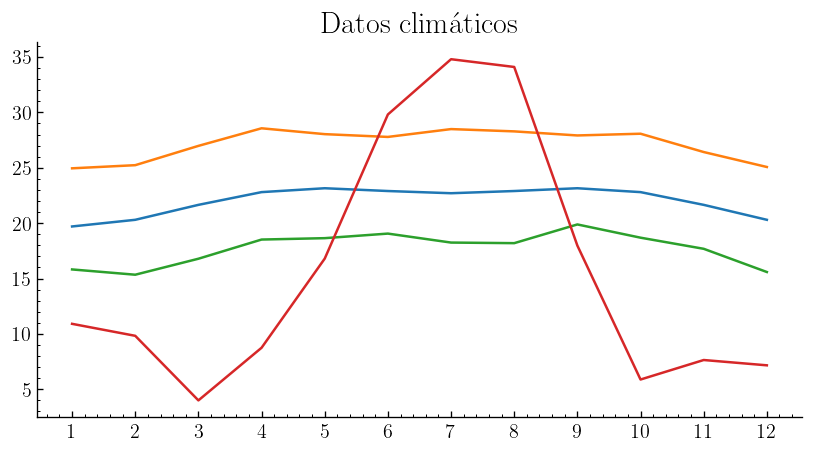

In [7]:
# ─── ANTES: cuatro curvas sin ninguna destacada, mensaje ausente ────────────
fig, ax = plt.subplots(figsize=(7, 4))

# Todas las series tienen el mismo peso visual → ninguna dice nada
ax.plot(meses, T_media, meses, T_max, meses, T_min, meses, lluvia/5)
ax.set_title('Datos climáticos')  # no dice qué concluir

ax.set_xticks(meses); 
#ax.set_xticklabels(nm)

plt.tight_layout()
plt.show()

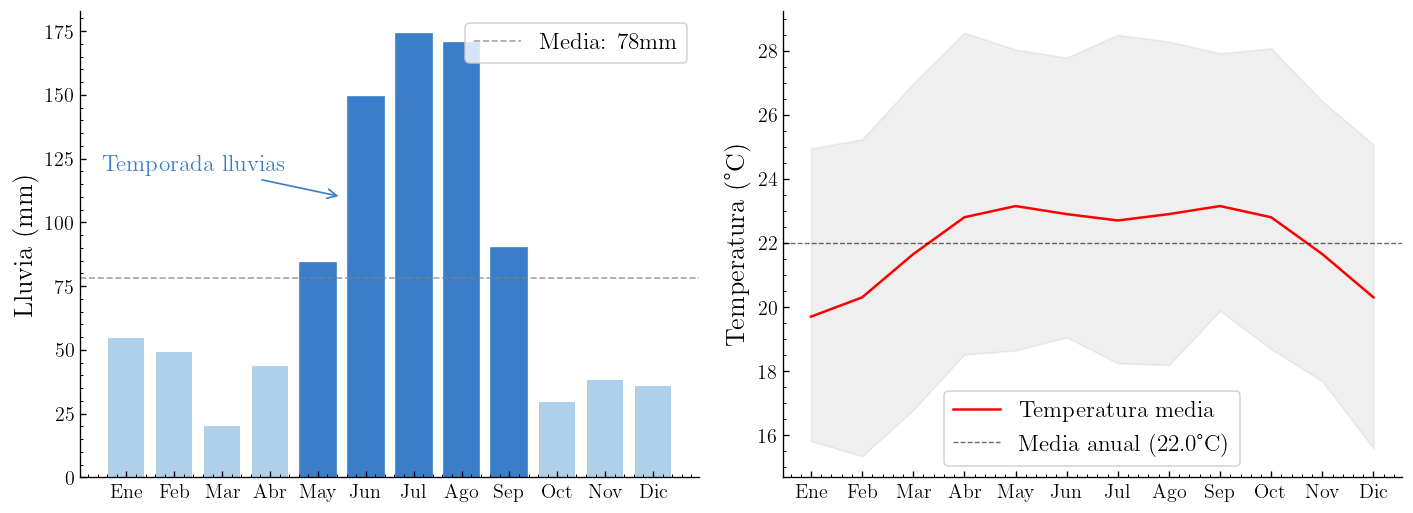

In [8]:
# ─── DESPUÉS: un mensaje claro → las dos temporadas lluviosas ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel principal: lluvia, con los meses lluviosos resaltados
ax = axes[0]
bars = ax.bar(meses, lluvia, color='#b0cfe8', width=0.75)  # base gris-azul

for i in [4, 5, 6, 7,8]:    # temporadas lluviosas: mayo-ago
    bars[i].set_color(COL_L)  # azul más intenso = mensaje visual
ax.axhline(lluvia.mean(), color='gray', lw=1, ls='--', alpha=0.7,
            label=f'Media: {lluvia.mean():.0f}mm')

ax.set_xticks(meses)
ax.set_xticklabels(nm)

ax.set_ylabel('Lluvia (mm)')

ax.legend(loc='upper right')

# Flechas que señalan cada temporada
ax.annotate('Temporada lluvias', xy=(5.5, 110), xytext=(0.5, 120),
             color=COL_L, arrowprops=dict(arrowstyle='->', color=COL_L))

# Panel secundario: temperatura en gris (es contexto, no el mensaje)
ax2 = axes[1]
ax2.fill_between(meses, T_min, T_max, alpha=0.12, color='gray')

ax2.plot(meses, T_media, color='r', lw=1.5, label='Temperatura media')

ax2.axhline(T_media.mean(), color='k', lw=0.8, ls='--', alpha=0.6, 
             label=f'Media anual ({T_media.mean():.1f}°C)')

#ax2.set_title('Temperatura')
ax2.set_xticks(meses); 
ax2.set_xticklabels(nm)

ax2.set_ylabel('Temperatura (°C)')
ax2.legend()

plt.tight_layout()
plt.show()

---
# Regla 3 — Adapta la figura al medio

Una figura para artículo tiene resolución fina y el lector puede detenerse. Una figura para presentación se ve desde lejos durante 30 segundos. **No uses la misma figura en ambos contextos.**

---
# Regla 4 — Los pies de figura no son opcionales

Un pie de figura (CAPTION) bien escrito explica qué muestra la figura, cómo leerla y qué significa lo que se ve. Sin él, la figura es incompleta incluso si es visualmente correcta.

---
# Regla 5 — No confíes en los valores por defecto

Los defaults de matplotlib están diseñados para funcionar en cualquier situación, no para ser óptimos en ninguna. Con ajustes mínimos y criterio, la figura mejora notablemente.

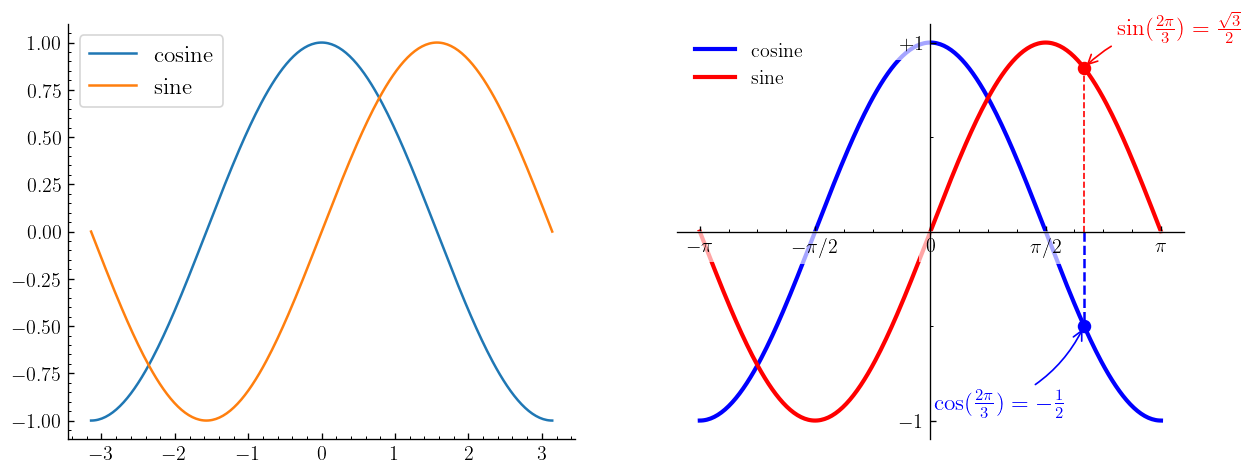

In [9]:
# 1. Configuración inicial de la figura
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 4.5))

# 2. Generación de datos
X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
C, S = np.cos(X), np.sin(X)

# Figura estándar sin ninguna regla aplicada
ax1.plot(X, C, label="cosine")
ax1.plot(X, S, label="sine")
ax1.legend()

# 3. Trazado de las curvas
ax2.plot(X, C, color="blue", linewidth=2.5, linestyle="-", label="cosine", zorder=1)
ax2.plot(X, S, color="red", linewidth=2.5, linestyle="-", label="sine", zorder=1)
ax2.legend()

# 4. Límites de los ejes (un 10% más amplios que los datos)
ax2.set_xlim(X.min() * 1.1, X.max() * 1.1)
ax2.set_ylim(C.min() * 1.1, C.max() * 1.1)
ax2.set_xlim(X.min() * 1.1, X.max() * 1.1)
ax2.set_ylim(S.min() * 1.1, S.max() * 1.1)

# 5. Configuración de marcas (ticks) y sus etiquetas usando LaTeX
ax2.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax2.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

ax2.set_yticks([-1, 1])
ax2.set_yticklabels([r'$-1$', r'$+1$'])

# 6. Modificación de los bordes (Spines) para que crucen por el centro (0,0)
ax2.xaxis.set_ticks_position('bottom')
ax2.spines['bottom'].set_position(('data', 0)) # Mover eje X al origen Y=0
ax2.yaxis.set_ticks_position('left')
ax2.spines['left'].set_position(('data', 0))   # Mover eje Y al origen X=0

# 7. Leyenda sin marco
ax2.legend(loc='upper left', frameon=False, fontsize=12)

# 8. Anotaciones matemáticas puntuales
t = 2 * np.pi / 3

# --- Anotación para el Seno (rojo) ---
# Línea punteada desde el eje X hasta la curva
ax2.plot([t, t], [0, np.sin(t)], color='red', linewidth=1, linestyle="--")
# Punto rojo de intersección
ax2.scatter([t, ], [np.sin(t), ], 50, color='red')

# Texto y flecha apuntando
ax2.annotate(r'$\sin(\frac{2\pi}{3})=\frac{\sqrt{3}}{2}$',
              xy=(t, np.sin(t)), xycoords='data',
              xytext=(20, 20), textcoords='offset points', fontsize=14, color='red',
              arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='red', lw=1))

# --- Anotación para el Coseno (azul) ---
# Línea punteada desde el eje X hasta la curva
ax2.plot([t, t], [0, np.cos(t)], color='blue', linewidth=1.5, linestyle="--")
# Punto azul de intersección
ax2.scatter([t, ], [np.cos(t), ], 50, color='blue')
# Texto y flecha apuntando
ax2.annotate(r'$\cos(\frac{2\pi}{3})=-\frac{1}{2}$',
             xy=(t, np.cos(t)), xycoords='data',
             xytext=(-90, -50), textcoords='offset points', fontsize=14, color='blue',
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='blue', lw=1))

# 9. Hacer que las etiquetas de los ejes sean legibles sobre las líneas
# Les agregamos un fondo blanco semitransparente
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='None', alpha=0.65))
    # zorder=10 fuerza a que el texto quede por encima de las líneas
    label.set_zorder(10)

# Mostrar la gráfica final
plt.show()

---
# Regla 6 — Usa el color con criterio

El color tiene dos usos legítimos: **codificar un valor escalar** (con un colormap adecuado) o **destacar un elemento** sobre los demás. Cualquier otro uso del color es decoración y añade ruido visual.

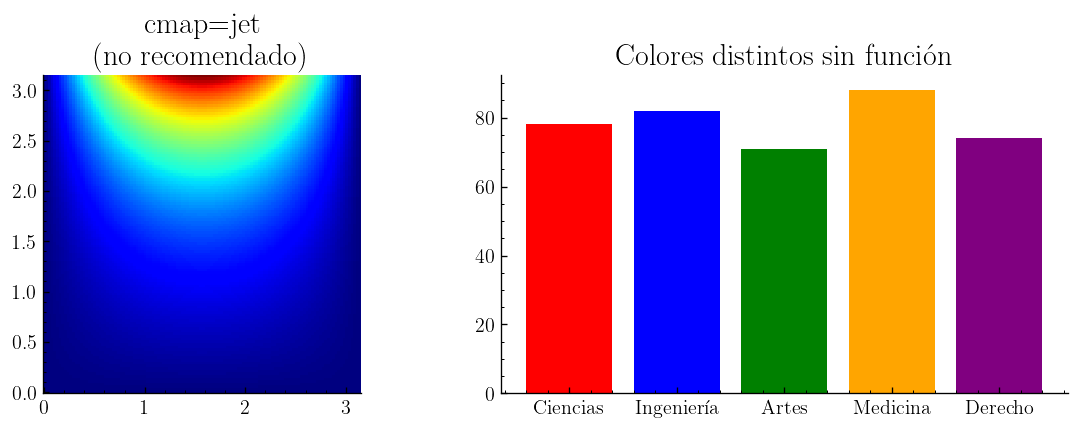

In [10]:
# ─── ANTES: colormaps incorrectos y colores arbitrarios ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# jet sobre datos secuenciales: crea bandas falsas (ver Regla 6 del notebook de colormaps)
axes[0].pcolormesh(X_e, Y_e, U_e, cmap='jet', shading='auto')
axes[0].set_title('cmap=jet \n(no recomendado)')
axes[0].set_aspect('equal')

# Colores arbitrarios en barras: el color no codifica nada
axes[1].bar(range(5), apr, color=['red','blue','green','orange','purple'])
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(fac)
axes[1].set_title('Colores distintos sin función')

plt.tight_layout()
plt.show()

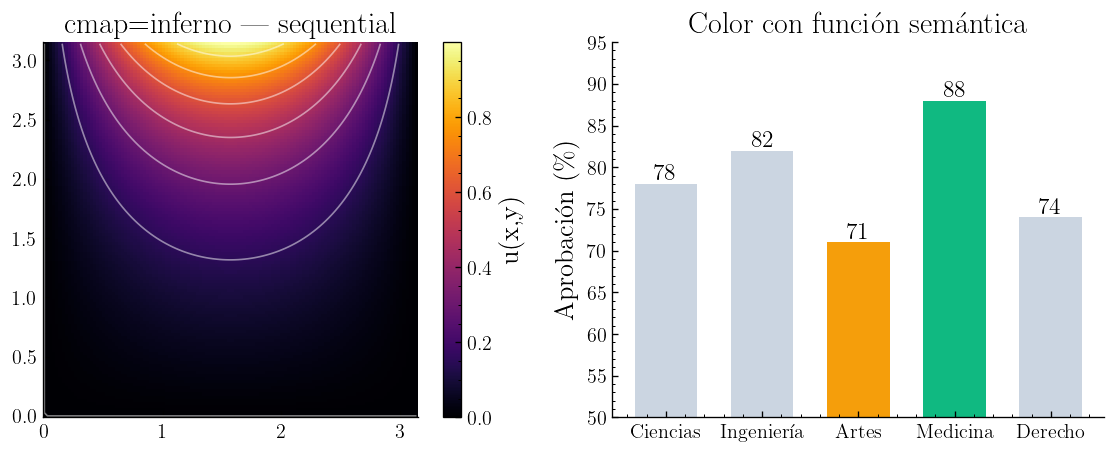

In [11]:
# ─── DESPUÉS: colormap correcto + color con función semántica ──────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# inferno: perceptualmente uniforme, sequential (datos 0→1)
pc = axes[0].pcolormesh(X_e, Y_e, U_e, cmap='inferno', shading='auto')
axes[0].contour(X_e, Y_e, U_e, levels=6, colors='white', linewidths=1, alpha=0.5)

plt.colorbar(pc, ax=axes[0], label='u(x,y)', fraction=0.046)

axes[0].set_title('cmap=inferno — sequential')
axes[0].set_aspect('equal')

# Color con función: gris para todos, color sólo para destacar máximo y mínimo
colores_bar = ['#CBD5E1'] * 5   # gris para todos
colores_bar[3] = '#10B981'      # verde: mayor aprobación (Medicina)
colores_bar[2] = '#F59E0B'      # ámbar: menor aprobación (Artes)
axes[1].bar(range(5), apr, color=colores_bar, edgecolor='none', width=0.65)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(fac)

axes[1].set_ylabel('Aprobación $(\%)$')
axes[1].set_ylim(50, 95)

axes[1].set_title('Color con función semántica')
for i, v in enumerate(apr):
    axes[1].text(i, v+0.5, f'{v}%', ha='center',
                 fontweight='bold' if i in [2, 3] else 'normal')
    
plt.tight_layout()
plt.show()

---
# Regla 7 — No engañes al lector

Un eje y truncado, una escala no lineal no declarada o un doble eje mal usado pueden hacer que diferencias pequeñas parezcan enormes o crear correlaciones visuales que no existen en los datos.

**Dato**: PIB per capita America Latina 2000-2022

Un eje truncado, una ventana de tiempo conveniente o un doble eje
pueden convertir crecimiento moderado en milagro economico.

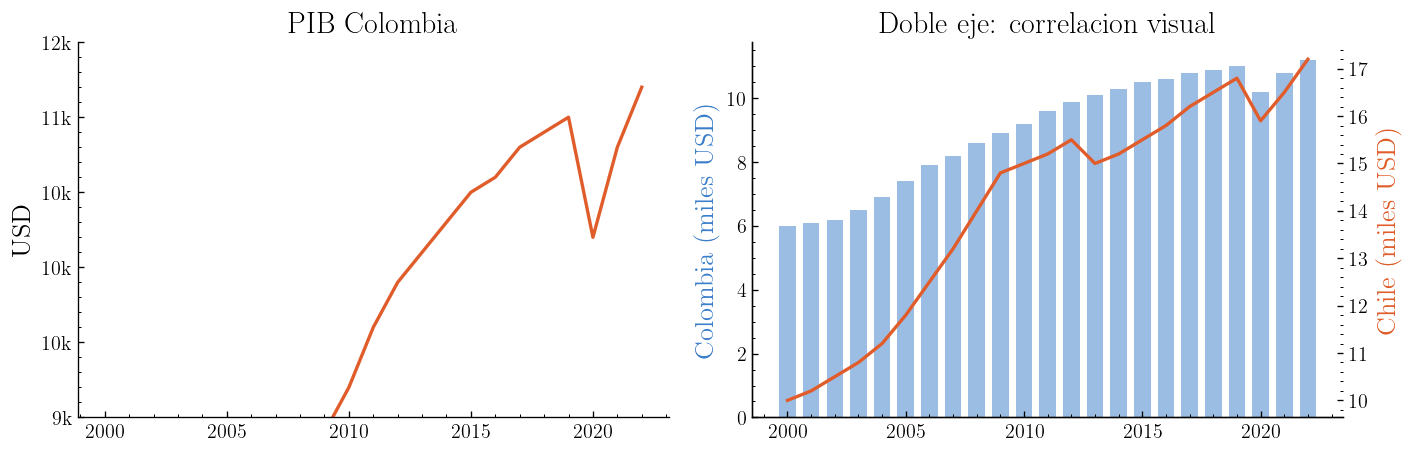

In [28]:
import pandas as pd

df_pib    = pd.read_csv("pib_latam.csv", index_col="anio")

# ANTES: eje truncado y doble eje enganoso
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Eje y truncado: diferencias de 15% parecen enormes
axes[0].plot(df_pib.index, df_pib["Colombia"], color=C["rojo"], lw=2)
axes[0].set_ylim(9000, 11500)  # truncado
axes[0].set_ylabel("USD")
axes[0].set_title("PIB Colombia")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))

# Doble eje: las escalas se manipulan para crear cualquier correlacion
ax2 = axes[1]; ax2t = ax2.twinx()

ax2.bar(df_pib.index, df_pib["Colombia"]/1000, color=C["azul"], alpha=0.5, width=0.7)
ax2t.plot(df_pib.index, df_pib["Chile"]/1000, color=C["rojo"], lw=2)

ax2.set_ylabel("Colombia (miles USD)", color=C["azul"])
ax2t.set_ylabel("Chile (miles USD)", color=C["rojo"])

axes[1].set_title("Doble eje: correlacion visual")

plt.tight_layout(); plt.show()


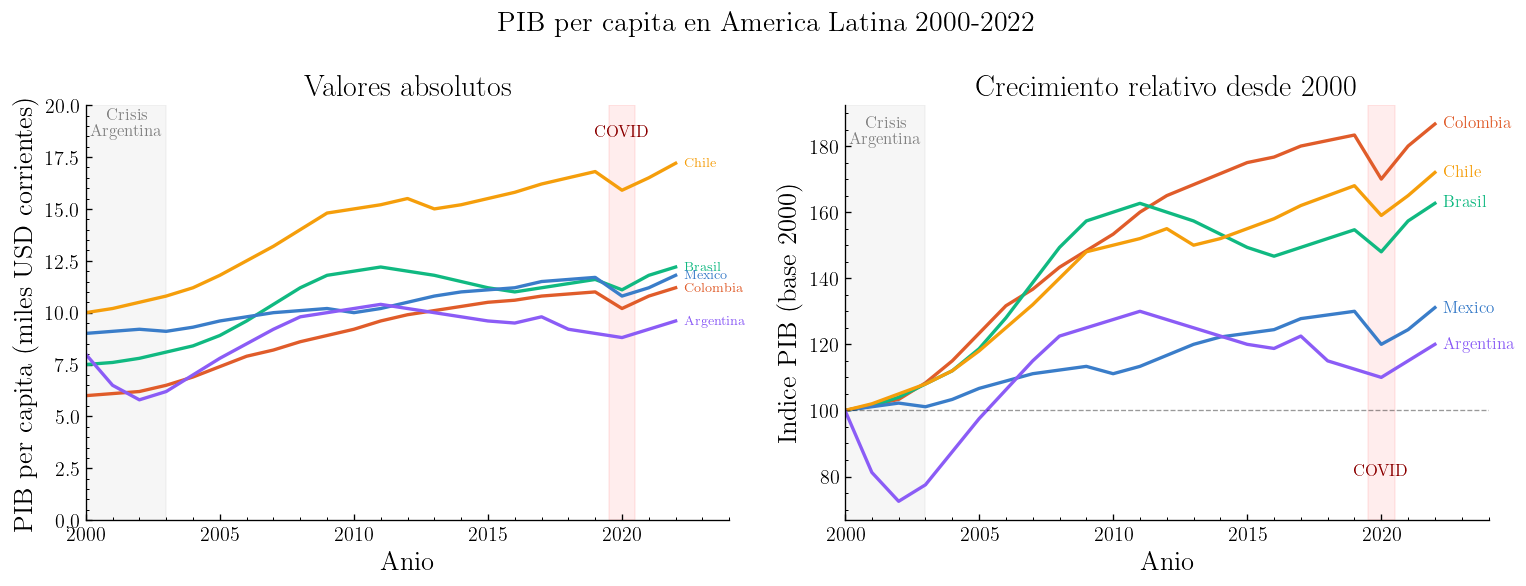

In [30]:
# DESPUES: eje desde 0, periodo completo, crecimiento relativo honesto
cols_paises = {
    "Colombia" : C["rojo"],
    "Brasil"   : C["verde"],
    "Mexico"   : C["azul"],
    "Chile"    : C["ambar"],
    "Argentina": C["violeta"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PIB per capita en America Latina 2000-2022")

# Panel izquierdo: valores absolutos desde 0
ax = axes[0]
for pais, col in cols_paises.items():
    ax.plot(df_pib.index, df_pib[pais]/1000, color=col, lw=2, label=pais)
    ax.text(2022.3, df_pib[pais].iloc[-1]/1000, pais, color=col, fontsize=8, va="center")

ax.set_ylim(0, 20)  # desde 0
ax.set_ylabel("PIB per capita (miles USD corrientes)")
ax.set_xlabel("Anio")
ax.set_title("Valores absolutos")
ax.set_xlim(2000, 2024)

# Anotar eventos historicos
ax.axvspan(2000, 2003, alpha=0.07, color="gray")
ax.text(2001.5, 18.5, "Crisis\nArgentina", ha="center", fontsize=10, color="gray")

ax.axvspan(2019.5, 2020.5, alpha=0.07, color="red")
ax.text(2020, 18.5, "COVID", ha="center", fontsize=10, color="darkred")

# Panel derecho: indice base 100 en 2000 -- compara tasas
ax2 = axes[1]
for pais, col in cols_paises.items():
    base = df_pib.loc[df_pib.index==2000, pais].values[0]
    relativo = df_pib[pais] / base * 100
    ax2.plot(df_pib.index, relativo, color=col, lw=2)
    ax2.text(2022.3, relativo.iloc[-1], pais, color=col, fontsize=10, va="center")
ax2.axhline(100, color="black", lw=0.8, ls="--", alpha=0.4)
ax2.set_ylabel("Indice PIB (base 2000)")
ax2.set_xlabel("Anio")
ax2.set_title("Crecimiento relativo desde 2000")
ax2.set_xlim(2000, 2024)

# Anotar eventos historicos
ax2.axvspan(2000, 2003, alpha=0.07, color="gray")
ax2.text(2001.5, 180.5, "Crisis\nArgentina", ha="center", fontsize=10, color="gray")

ax2.axvspan(2019.5, 2020.5, alpha=0.07, color="red")
ax2.text(2020, 80.5, "COVID", ha="center", fontsize=10, color="darkred")

plt.tight_layout(); plt.show()


## Otro ejemplo:
Una escala lineal sobre datos que varían órdenes de magnitud es tan engañosa como un eje truncado.

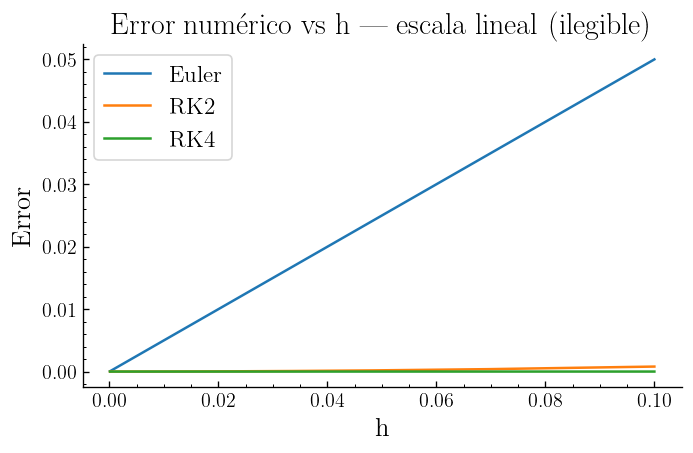

RK4 es invisible: su error está en el rango 10^-19 a 10^-7,
pero la escala lineal lo aplana contra el eje.


In [52]:
# ─── ANTES: error numérico en escala lineal ────────────────────────────────
# Los datos varían 10^7 órdenes de magnitud: la escala lineal los aplana
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(h, e_eu,  label='Euler')
ax.plot(h, e_rk2, label='RK2')
ax.plot(h, e_rk4, label='RK4')   # RK4 invisible: error 10^-7 vs Euler 10^-1

ax.set_xlabel('h')
ax.set_ylabel('Error')
ax.set_title('Error numérico vs h')

ax.legend()
plt.tight_layout()
plt.show()

print('RK4 es invisible: su error está en el rango 10^-19 a 10^-7,')
print('pero la escala lineal lo aplana contra el eje.')

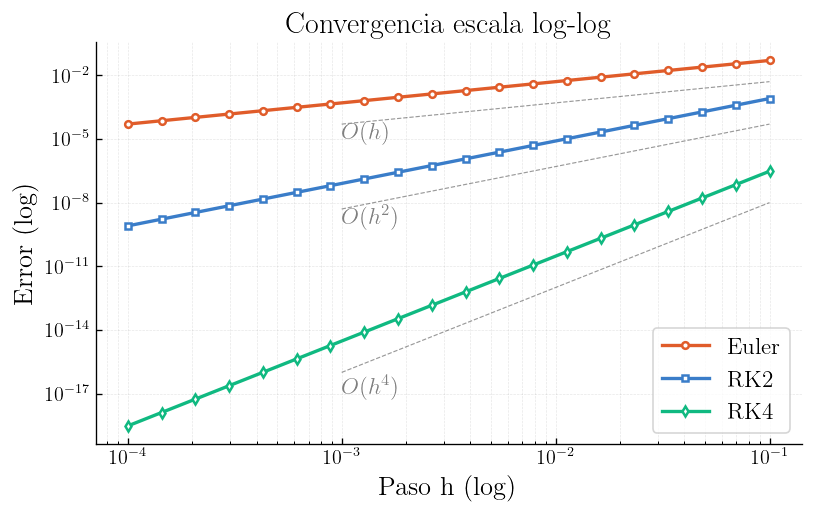

In [70]:
# ─── DESPUÉS: escala log-log con pendientes anotadas ──────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

# loglog: escala logarítmica en ambos ejes
# En log-log, una potencia O(h^p) aparece como una recta de pendiente p
ax.loglog(h, e_eu,  color=COL_T, lw=2, marker='o', ms=4,
            markerfacecolor='white', markeredgewidth=1.5, label='Euler')
ax.loglog(h, e_rk2, color=COL_L, lw=2, marker='s', ms=4,
            markerfacecolor='white', markeredgewidth=1.5, label='RK2')
ax.loglog(h, e_rk4, color='#10B981', lw=2, marker='d', ms=4,
            markerfacecolor='white', markeredgewidth=1.5, label='RK4')

# Líneas de referencia de pendiente teórica
h_ref = np.array([1e-3, 1e-1])
ax.loglog(h_ref, 0.05  * h_ref**1, 'k--', lw=0.7, alpha=0.4)
ax.loglog(h_ref, 0.005 * h_ref**2, 'k--', lw=0.7, alpha=0.4)
ax.loglog(h_ref, 1e-4  * h_ref**4, 'k--', lw=0.7, alpha=0.4)
ax.text(1e-3, 1e-5,  '$O(h)$', color='gray')
ax.text(1e-3, 1e-9,  '$O(h^2)$', color='gray')
ax.text(1e-3, 1e-17,  '$O(h^4)$', color='gray')

ax.set_xlabel('Paso h (log)');
ax.set_ylabel('Error (log)')
ax.set_title('Convergencia escala log-log')

ax.legend( )
ax.grid(True, which='both', alpha=0.2, linewidth=0.4)

plt.tight_layout()

plt.show()

---
# Regla 8 — Evita el chartjunk

El chartjunk (Tufte, 1983) es todo elemento visual que no codifica información: fondos de colores, bordes gruesos, grid brillante, sombras 3D, colores sin función. Cada píxel debe justificar su existencia.

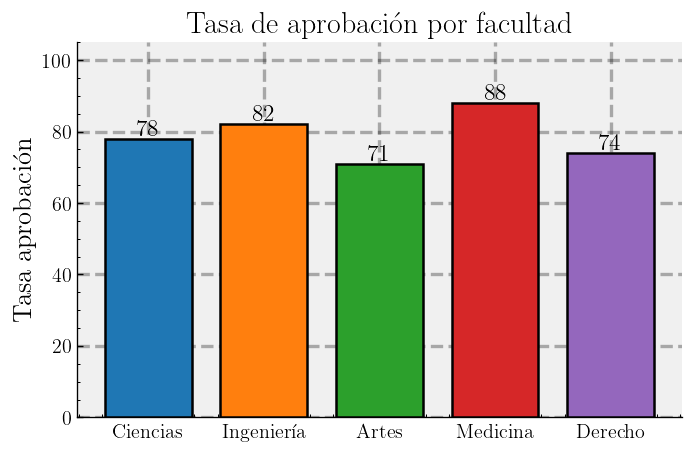

Fondo gris, grid blanco grueso, 5 colores distintos: todo es decoración.


In [35]:
# ─── ANTES: cargado de decoración visual ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

bar_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']  # un color por barra
bars = ax.bar(range(5), apr, color=bar_colors, width=0.75,
              edgecolor='black', linewidth=1.5, zorder=3)  # bordes gruesos

ax.set_facecolor('#f0f0f0')                # fondo gris

ax.grid(True, color='k', linewidth=2, zorder=2)  # grid grueso y blanco
ax.set_xticks(range(5)); ax.set_xticklabels(fac)
ax.set_ylabel('Tasa aprobación');
ax.set_ylim(0, 105)

for bar, v in zip(bars, apr):
    ax.text(bar.get_x()+bar.get_width()/2, v+1, f'{v}%',
            ha='center', fontweight='bold', color='black')
ax.set_title('Tasa de aprobación por facultad')

plt.tight_layout()

plt.show()

print('Fondo gris, grid blanco grueso, 5 colores distintos: todo es decoración.')

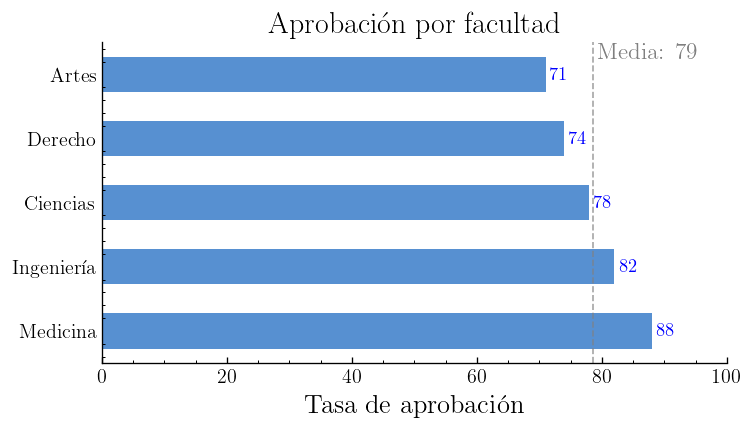

In [51]:
# ─── DESPUÉS: minimalista — sólo lo que cuenta ──────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.8))

# Ordenar de mayor a menor: facilita la comparación
oi = np.argsort(apr)[::-1]
fo = [fac[i] for i in oi]; ao = apr[oi]

# Barras horizontales: más legibles con etiquetas largas
ax.barh(range(5), ao, color=COL_L, alpha=0.85, height=0.55)

ax.set_yticks(range(5))
ax.set_yticklabels(fo)
ax.set_xlabel('Tasa de aprobación'); ax.set_xlim(0, 100)

# Sin bordes laterales: el eje y ya está dado por las etiquetas
#ax.spines['left'].set_visible(False)
ax.tick_params(left=False)   # sin ticks del eje y

# Valores anotados: el lector no tiene que estimar
for i, v in enumerate(ao):
    ax.text(v+0.7, i, f'{v}%', va='center',color='b',fontsize=11, fontweight='bold')

# Línea de media: referencia sin ruido visual
ax.axvline(apr.mean(), color='gray', lw=1, ls='--', alpha=0.7)
ax.text(apr.mean()+0.7, 4.25, f'Media: {apr.mean():.0f}%', color='gray')

ax.set_title('Aprobación por facultad')

plt.tight_layout()
plt.show()

---
# Regla 9 — La figura debe ser reproducible

*(Adaptación de la regla original "Message beats beauty")* 
En ciencia computacional, toda figura debe poder ser regenerada exactamente con el código fuente. Esto requiere: semilla fija, rutas de datos explícitas, código comentado y versiones de las librerías documentadas.

---
# Regla 10 — Conoce tu biblioteca

*(Adaptación de la regla original "Get the right tool")* 
Usar la función correcta de matplotlib (o de la biblioteca correcta) cambia completamente la capacidad de comunicar. Una escala lineal sobre datos que varían órdenes de magnitud es tan engañosa como un eje truncado.